# WEMA — Knowledge Base Labelling & Visualization

**Women's Emergency Medical AI · Capstone artifact**

This notebook documents and visualizes the clinical knowledge base that grounds WEMA's RAG layer.

It produces:
1. **A labelled manifest** — structured metadata (title, source, year, emergency type, care phase, doc type) for every document.
2. **Chunk-level counts** — how many retrievable chunks each document contributed to the ChromaDB index, read live from the persisted store.
3. **Capstone-ready charts** — composition of the knowledge base by every dimension above.

**Verified store state this notebook is built against:** 19 documents, 8,750 chunks, collection `wema_maternal_health`, embedding model `sentence-transformers/all-MiniLM-L6-v2`.

## 1. Configuration

Edit the paths to match your machine, then run top to bottom.

In [1]:
import os, glob, collections
import pandas as pd
import matplotlib.pyplot as plt

# ---- paths ----
PDF_DIR    = r"C:\Users\pampam\WEMA\WEMA-Women-s-Emergency-Medical-AI\data\pdfs"
CHROMA_DIR = r"C:\Users\pampam\WEMA\WEMA-Women-s-Emergency-Medical-AI\knowledge_base"
COLLECTION_NAME = "wema_maternal_health"
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"   # matches rag.py
OUT_DIR    = r"reports\kb"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- WEMA palette ----
GREEN, CORAL, INK, GREY = "#1D9E75", "#D85A30", "#2C2C2A", "#888780"
BLUE, PLUM = "#3A7CA5", "#7B6D8D"
%matplotlib inline

## 2. Document-level labels

One entry per document, keyed by the **filename as stored in ChromaDB's `source` metadata** (so the chunk counts join cleanly).

| field | meaning |
|---|---|
| `title` | readable name |
| `source` | publishing body — WHO / ACOG / AHA-AAP / Cochrane / National / Other |
| `year` | publication year (`None` where unconfirmed — excluded from the year chart) |
| `emergency_type` | clinical topic; bridges the KB to the evaluation scenarios |
| `care_phase` | antenatal / intrapartum / postpartum / neonatal / cross-cutting |
| `doc_type` | clinical_guideline / practice_bulletin / recommendation / systematic_review / statement / provider_guide |

> Labels are classified from filenames, not extracted from the PDFs. Confirm any field marked **VERIFY** before it goes in the dissertation.

In [2]:
# keyed by the exact filename in Chroma's `source` path (basename)
KB_LABELS = {
    "9789241549356-eng.pdf": dict(
        title="Managing Complications in Pregnancy & Childbirth (MCPC)",
        source="WHO", year=2017,  # VERIFY edition/year
        emergency_type="Multiple (obstetric)", care_phase="cross-cutting",
        doc_type="clinical_guideline"),

    "WHO_Maternal_Guidelines_2025.pdf": dict(
        title="WHO Maternal Guidelines 2025",
        source="WHO", year=2025,
        emergency_type="Multiple (maternal)", care_phase="cross-cutting",
        doc_type="clinical_guideline"),

    "managing pregnany for midwife and docors.pdf": dict(
        title="Managing Pregnancy — Guide for Midwives & Doctors",
        source="Other", year=None,  # VERIFY publisher/title/year (likely WHO IMPAC PCPNC)
        emergency_type="Multiple (obstetric)", care_phase="cross-cutting",
        doc_type="provider_guide"),

    "Clinical management of obstetric and neonatal emergencies in Africa.pdf": dict(
        title="Clinical Management of Obstetric & Neonatal Emergencies in Africa",
        source="Other", year=None,  # VERIFY year/publisher
        emergency_type="Multiple (obstetric & neonatal)", care_phase="cross-cutting",
        doc_type="clinical_guideline"),

    "lee-et-al-2025-part-5-neonatal-resuscitation-2025-american-heart-association-and-american-academy-of-pediatrics.pdf": dict(
        title="AHA/AAP 2025 — Part 5: Neonatal Resuscitation",
        source="AHA-AAP", year=2025,
        emergency_type="Neonatal resuscitation", care_phase="neonatal",
        doc_type="clinical_guideline"),

    "9789240115835-eng.pdf": dict(
        title="WHO maternal/newborn care guideline",
        source="WHO", year=None,  # VERIFY exact title/year (ISBN 9789240115835)
        emergency_type="Multiple (maternal & newborn)", care_phase="cross-cutting",
        doc_type="clinical_guideline"),

    "WHO recommendations on antiplatelet agents for the prevention of pre-eclampsia.pdf": dict(
        title="WHO Recommendations — Antiplatelet Agents for Pre-eclampsia Prevention",
        source="WHO", year=2021,
        emergency_type="Pre-eclampsia / Eclampsia", care_phase="antenatal",
        doc_type="recommendation"),

    "WHO recommendations Uterotonics for prevention of postpartum haemorrhage.pdf": dict(
        title="WHO Recommendations — Uterotonics for Prevention of PPH",
        source="WHO", year=2018,
        emergency_type="Postpartum haemorrhage", care_phase="postpartum",
        doc_type="recommendation"),

    "Treatment of Perinatal Mental Health Conditions.pdf": dict(
        title="Treatment of Perinatal Mental Health Conditions",
        source="Other", year=None,  # VERIFY publisher/year
        emergency_type="Perinatal mental health", care_phase="postpartum",
        doc_type="clinical_guideline"),

    "Gestational_Hypertension_and_Preeclampsia_ACOG_Practice_Bulletin,_Number_222_1605448006.pdf": dict(
        title="ACOG Practice Bulletin 222 — Gestational Hypertension & Pre-eclampsia",
        source="ACOG", year=2020,
        emergency_type="Pre-eclampsia / Eclampsia", care_phase="antenatal",
        doc_type="practice_bulletin"),

    "WHO recommendations on the management of sickle-cell disease during pregnancy, childbirth and the interpregnancy period.pdf": dict(
        title="WHO Recommendations — Sickle Cell Disease in Pregnancy & Childbirth",
        source="WHO", year=2025,  # VERIFY year
        emergency_type="Sickle cell disease", care_phase="cross-cutting",
        doc_type="recommendation"),

    "WHO recommendations on the assessment of postpartum blood loss and use of a treatment bundle for postpartum haemorrhage.pdf": dict(
        title="WHO Recommendations — Assessment of Postpartum Blood Loss & PPH Treatment Bundle",
        source="WHO", year=2023,  # VERIFY year
        emergency_type="Postpartum haemorrhage", care_phase="postpartum",
        doc_type="recommendation"),

    "WHO recommendations on care for women with diabetes during pregnancy.pdf": dict(
        title="WHO Recommendations — Care for Women with Diabetes During Pregnancy",
        source="WHO", year=2016,  # VERIFY year
        emergency_type="Gestational diabetes", care_phase="antenatal",
        doc_type="recommendation"),

    "postpartum-hemorrhage-number-183-october-2017.pdf": dict(
        title="ACOG Practice Bulletin 183 — Postpartum Hemorrhage",
        source="ACOG", year=2017,
        emergency_type="Postpartum haemorrhage", care_phase="postpartum",
        doc_type="practice_bulletin"),

    "Essential Newborn Care (ENC) Provider Guide.pdf": dict(
        title="Essential Newborn Care (ENC) Provider Guide",
        source="Other", year=None,  # VERIFY publisher/year
        emergency_type="Newborn care", care_phase="neonatal",
        doc_type="provider_guide"),

    "policy of interventionist versus expectant management of severe pre-eclampsia before term.pdf": dict(
        title="Interventionist vs Expectant Management of Severe Pre-eclampsia Before Term",
        source="Cochrane", year=2018,  # VERIFY year
        emergency_type="Pre-eclampsia / Eclampsia", care_phase="antenatal",
        doc_type="systematic_review"),

    "Consolidated guidelines for the prevention, diagnosis and treatment of postpartum haemorrhage(2025).pdf": dict(
        title="WHO Consolidated Guidelines — Prevention, Diagnosis & Treatment of PPH",
        source="WHO", year=2025,
        emergency_type="Postpartum haemorrhage", care_phase="postpartum",
        doc_type="clinical_guideline"),

    "Statement on maternal sepsis.pdf": dict(
        title="WHO Statement on Maternal Sepsis",
        source="WHO", year=2017,
        emergency_type="Sepsis", care_phase="postpartum",
        doc_type="statement"),

    "National-MEWS-Final-version.pdf": dict(
        title="National Maternal Early Warning System (MEWS)",
        source="National", year=None,  # VERIFY country/year
        emergency_type="Early warning / monitoring", care_phase="cross-cutting",
        doc_type="clinical_guideline"),
}

print(f"{len(KB_LABELS)} documents labelled.")

19 documents labelled.


## 3. Build the manifest

Assemble labels into a DataFrame and cross-check against the PDFs on disk, flagging anything unlabelled or missing.

In [3]:
rows = [dict(filename=f, **meta) for f, meta in KB_LABELS.items()]
manifest = pd.DataFrame(rows)

if os.path.isdir(PDF_DIR):
    on_disk = {os.path.basename(p) for p in glob.glob(os.path.join(PDF_DIR, "*.pdf"))}
    unlabelled   = on_disk - set(KB_LABELS)
    missing_file = set(KB_LABELS) - on_disk
    if unlabelled:
        print("WARNING — on disk but not labelled (add to KB_LABELS):")
        for f in sorted(unlabelled): print("   -", f)
    if missing_file:
        print("NOTE — labelled but not on disk (check filename/path):")
        for f in sorted(missing_file): print("   -", f)
    if not unlabelled and not missing_file:
        print(f"All {len(on_disk)} on-disk PDFs are labelled and accounted for.")
else:
    print(f"PDF_DIR '{PDF_DIR}' not found — skipping on-disk cross-check.")

manifest

PDF_DIR 'C:\Users\pampam\WEMA\WEMA-Women-s-Emergency-Medical-AI\data\pdfs' not found — skipping on-disk cross-check.


,filename,title,source,year,emergency_type,care_phase,doc_type
0,9789241549356-eng.pdf,Managing Complications in Pregnancy & Childbir...,WHO,2017.0,Multiple (obstetric),cross-cutting,clinical_guideline
1,WHO_Maternal_Guidelines_2025.pdf,WHO Maternal Guidelines 2025,WHO,2025.0,Multiple (maternal),cross-cutting,clinical_guideline
2,managing pregnany for midwife and docors.pdf,Managing Pregnancy — Guide for Midwives & Doctors,Other,NaN,Multiple (obstetric),cross-cutting,provider_guide
3,Clinical management of obstetric and neonatal ...,Clinical Management of Obstetric & Neonatal Em...,Other,NaN,Multiple (obstetric & neonatal),cross-cutting,clinical_guideline
4,lee-et-al-2025-part-5-neonatal-resuscitation-2...,AHA/AAP 2025 — Part 5: Neonatal Resuscitation,AHA-AAP,2025.0,Neonatal resuscitation,neonatal,clinical_guideline
5,9789240115835-eng.pdf,WHO maternal/newborn care guideline,WHO,NaN,Multiple (maternal & newborn),cross-cutting,clinical_guideline
6,WHO recommendations on antiplatelet agents for...,WHO Recommendations — Antiplatelet Agents for ...,WHO,2021.0,Pre-eclampsia / Eclampsia,antenatal,recommendation
7,WHO recommendations Uterotonics for prevention...,WHO Recommendations — Uterotonics for Preventi...,WHO,2018.0,Postpartum haemorrhage,postpartum,recommendation
8,Treatment of Perinatal Mental Health Condition...,Treatment of Perinatal Mental Health Conditions,Other,NaN,Perinatal mental health,postpartum,clinical_guideline
9,Gestational_Hypertension_and_Preeclampsia_ACOG...,ACOG Practice Bulletin 222 — Gestational Hyper...,ACOG,2020.0,Pre-eclampsia / Eclampsia,antenatal,practice_bulletin


## 4. Chunk counts from ChromaDB

Reads the persisted store and counts chunks per document. The store records `source` as a full Windows path, so we take the basename to join against the manifest.

If ChromaDB isn't reachable the manifest still works — the `chunks` column stays empty and the chunk chart is skipped.

In [4]:
def add_chunk_counts(df, chroma_dir, collection_name):
    try:
        import chromadb
        client = chromadb.PersistentClient(path=chroma_dir)
        col = client.get_collection(collection_name)
        data = col.get(include=["metadatas"])
        raw = collections.Counter(
            (m or {}).get("source", "?").replace("\\", "/").split("/")[-1]
            for m in data["metadatas"]
        )
        df["chunks"] = df["filename"].map(raw).fillna(0).astype(int)
        print(f"ChromaDB: {sum(raw.values())} chunks across {len(raw)} sources.")
        zero = [df.loc[i,"filename"] for i in df.index if df.loc[i,"chunks"] == 0]
        if zero:
            print("0 chunks (labelled but not in store):")
            for z in zero: print("   -", z)
    except Exception as e:
        print(f"ChromaDB not read ({e}). Chunk column left empty.")
        df["chunks"] = pd.NA
    return df

manifest = add_chunk_counts(manifest, CHROMA_DIR, COLLECTION_NAME)
manifest[["title", "source", "chunks"]]

ChromaDB not read (Collection [wema_maternal_health] does not exist). Chunk column left empty.


,title,source,chunks
0,Managing Complications in Pregnancy & Childbir...,WHO,<NA>
1,WHO Maternal Guidelines 2025,WHO,<NA>
2,Managing Pregnancy — Guide for Midwives & Doctors,Other,<NA>
3,Clinical Management of Obstetric & Neonatal Em...,Other,<NA>
4,AHA/AAP 2025 — Part 5: Neonatal Resuscitation,AHA-AAP,<NA>
5,WHO maternal/newborn care guideline,WHO,<NA>
6,WHO Recommendations — Antiplatelet Agents for ...,WHO,<NA>
7,WHO Recommendations — Uterotonics for Preventi...,WHO,<NA>
8,Treatment of Perinatal Mental Health Conditions,Other,<NA>
9,ACOG Practice Bulletin 222 — Gestational Hyper...,ACOG,<NA>


## 5. (Optional) Live retrieval sanity check

Runs one query through the **same** MiniLM + Chroma stack `rag.py` uses, confirming retrieval returns real source attributions end to end. Skip if you only need the charts.

In [5]:
try:
    from langchain_community.embeddings import HuggingFaceEmbeddings
    from langchain_community.vectorstores import Chroma
    emb = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL, model_kwargs={"device": "cpu"})
    vs = Chroma(persist_directory=CHROMA_DIR, embedding_function=emb, collection_name=COLLECTION_NAME)
    hits = vs.similarity_search("woman bleeding heavily after childbirth at home", k=4)
    print("sources:", sorted({h.metadata.get("source_file","WHO") for h in hits}))
    print("\nsample:\n", hits[0].page_content[:220])
except Exception as e:
    print("Retrieval check skipped:", e)

Retrieval check skipped: No module named 'langchain_community'


## 6. Save the manifest

In [6]:
csv_path  = os.path.join(OUT_DIR, "knowledge_base_manifest.csv")
xlsx_path = os.path.join(OUT_DIR, "knowledge_base_manifest.xlsx")
manifest.to_csv(csv_path, index=False)
try:
    manifest.to_excel(xlsx_path, index=False)
    print("Saved:", csv_path, "and", xlsx_path)
except Exception as e:
    print("Saved:", csv_path, f"(xlsx skipped: {e} — pip install openpyxl)")

Saved: reports\kb/knowledge_base_manifest.csv and reports\kb/knowledge_base_manifest.xlsx


## 7. Chart helpers

In [7]:
def style(ax, title):
    ax.set_title(title, fontsize=13, fontweight="bold", color=INK, pad=12)
    ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(colors=INK)
    for s in ("left","bottom"): ax.spines[s].set_color(GREY)

def hbar(ax, counts, color=GREEN):
    counts = counts.sort_values()
    ax.barh(counts.index, counts.values, color=color)
    for i, v in enumerate(counts.values):
        ax.text(v + max(counts.values)*0.01, i, str(int(v)), va="center", fontsize=10, color=INK)
    ax.set_xlabel("documents", fontsize=10, color=GREY)

def vbar(ax, counts, color=GREEN):
    ax.bar([str(x) for x in counts.index], counts.values, color=color)
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.02, str(int(v)), ha="center", fontsize=10, color=INK)
    ax.set_ylabel("documents", fontsize=10, color=GREY)

def save(fig, name):
    p = os.path.join(OUT_DIR, name); fig.savefig(p, dpi=200, bbox_inches="tight"); print("saved", p)

## 8. Documents by emergency type

saved reports\kb/kb_by_emergency_type.png


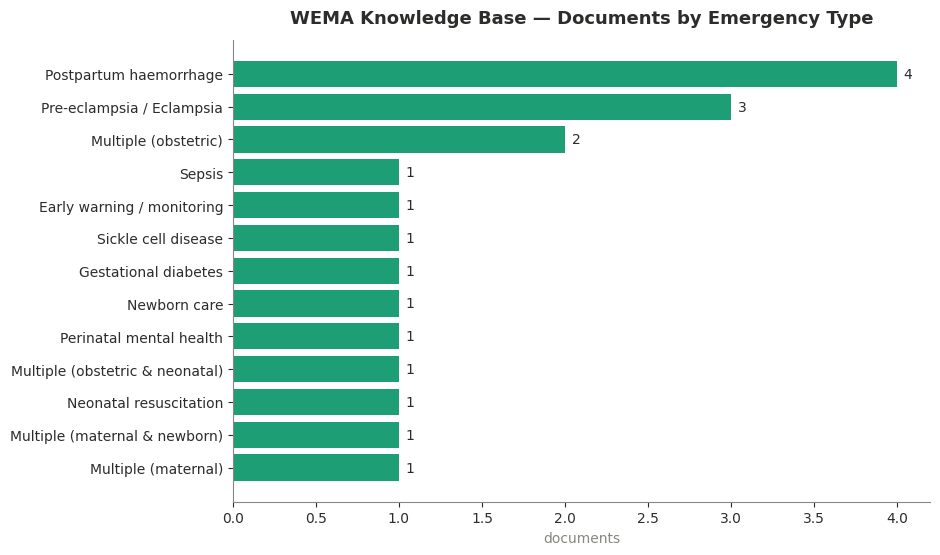

In [8]:
fig, ax = plt.subplots(figsize=(9,6))
hbar(ax, manifest["emergency_type"].value_counts(), GREEN)
style(ax, "WEMA Knowledge Base — Documents by Emergency Type")
save(fig, "kb_by_emergency_type.png"); plt.show()

## 9. Documents by source

saved reports\kb/kb_by_source.png


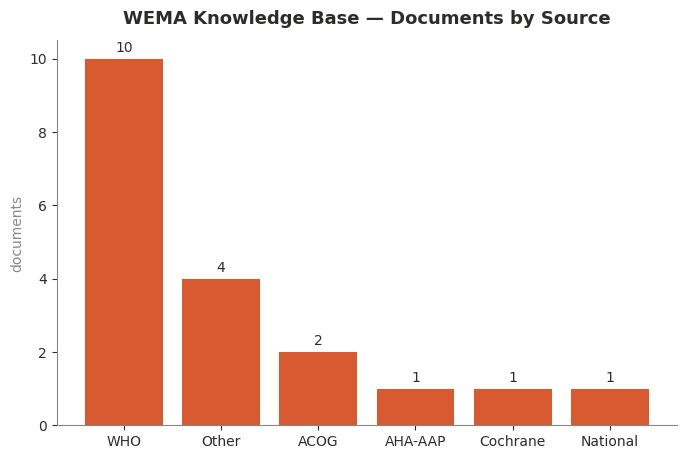

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
vbar(ax, manifest["source"].value_counts(), CORAL)
style(ax, "WEMA Knowledge Base — Documents by Source")
save(fig, "kb_by_source.png"); plt.show()

## 10. Documents by year

saved reports\kb/kb_by_year.png


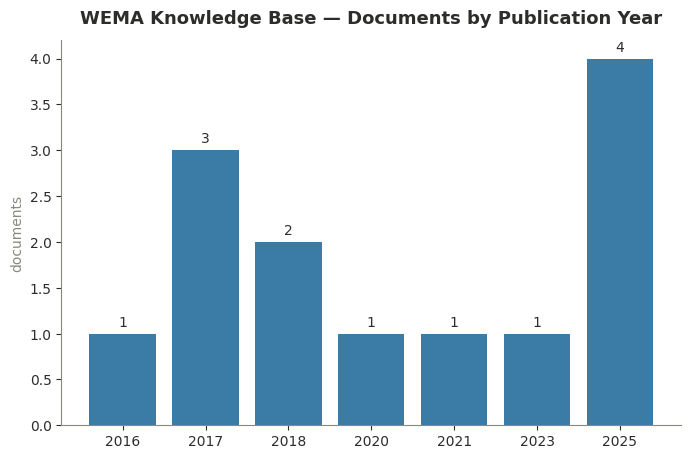

In [10]:
yr = manifest.dropna(subset=["year"]).copy(); yr["year"] = yr["year"].astype(int)
fig, ax = plt.subplots(figsize=(8,5))
vbar(ax, yr["year"].value_counts().sort_index(), BLUE)
style(ax, "WEMA Knowledge Base — Documents by Publication Year")
save(fig, "kb_by_year.png"); plt.show()

## 11. Documents by care phase

saved reports\kb/kb_by_care_phase.png


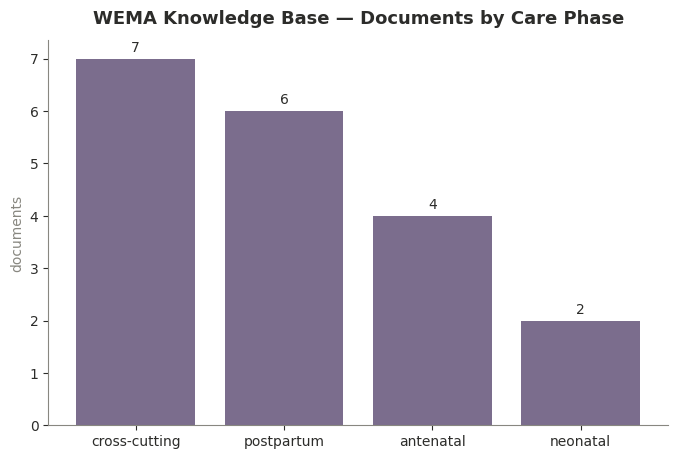

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
vbar(ax, manifest["care_phase"].value_counts(), PLUM)
style(ax, "WEMA Knowledge Base — Documents by Care Phase")
save(fig, "kb_by_care_phase.png"); plt.show()

## 12. Chunks ingested per document

The figure to lead with in the methodology — it reflects what RAG can actually retrieve at `k=4`, not just how many files exist.

**Caveat for the writeup:** chunk count tracks document *length*, so long consolidated guidelines dominate. The two largest documents hold a large share of the index; name this in the chapter so it reads as a known property, not an oversight.

In [12]:
if manifest["chunks"].notna().any() and manifest["chunks"].sum() > 0:
    cc = manifest.set_index("title")["chunks"].sort_values()
    fig, ax = plt.subplots(figsize=(10,8))
    ax.barh(cc.index, cc.values, color=GREEN)
    for i, v in enumerate(cc.values):
        ax.text(v + max(cc.values)*0.01, i, str(int(v)), va="center", fontsize=9, color=INK)
    style(ax, "WEMA Knowledge Base — Chunks Ingested per Document")
    ax.set_xlabel("chunks in ChromaDB", fontsize=10, color=GREY)
    save(fig, "kb_chunks_per_source.png"); plt.show()
else:
    print("No chunk data — connect ChromaDB (step 4) to generate this chart.")

No chunk data — connect ChromaDB (step 4) to generate this chart.


## 13. Overview panel

saved reports\kb/kb_overview.png


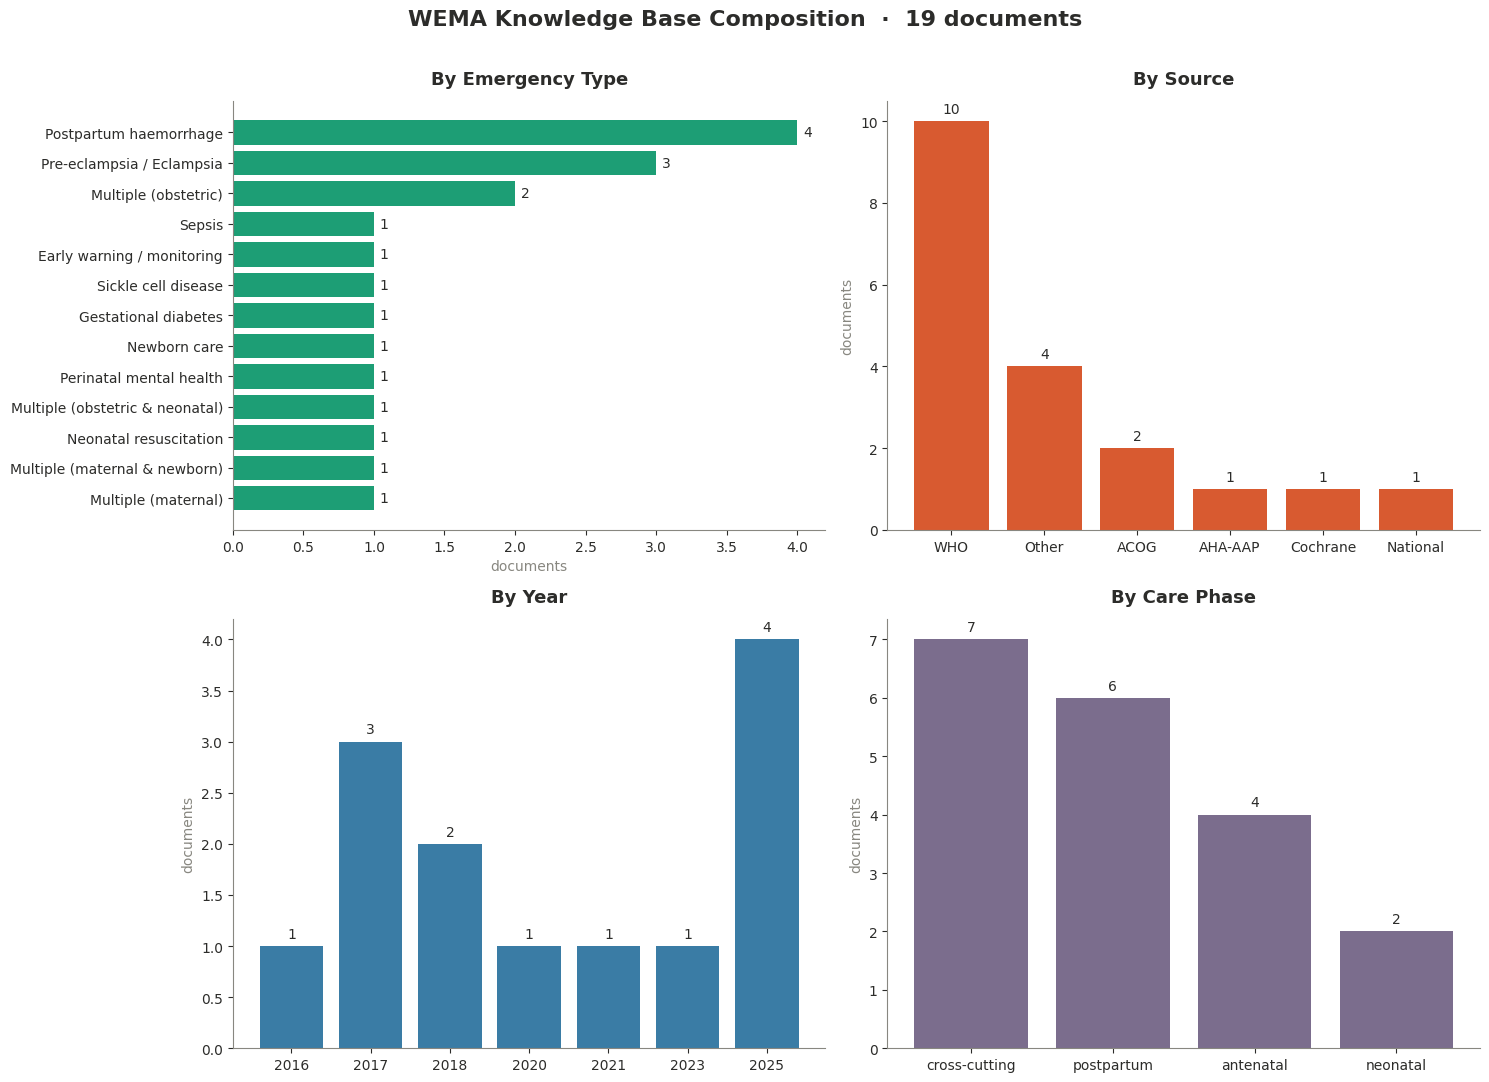

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(15,11))
hbar(axs[0,0], manifest["emergency_type"].value_counts(), GREEN); style(axs[0,0], "By Emergency Type")
vbar(axs[0,1], manifest["source"].value_counts(), CORAL);        style(axs[0,1], "By Source")
vbar(axs[1,0], yr["year"].value_counts().sort_index(), BLUE);    style(axs[1,0], "By Year")
vbar(axs[1,1], manifest["care_phase"].value_counts(), PLUM);     style(axs[1,1], "By Care Phase")
fig.suptitle(f"WEMA Knowledge Base Composition  ·  {len(manifest)} documents",
             fontsize=16, fontweight="bold", color=INK)
fig.tight_layout(rect=[0,0,1,0.97])
save(fig, "kb_overview.png"); plt.show()

## Summary

- **19 documents · 8,750 chunks**, collection `wema_maternal_health`, embedding model `sentence-transformers/all-MiniLM-L6-v2`.
- Document-level labelling describes the KB; chunk-level counts show what RAG retrieves.
- Manifest (CSV + XLSX) and all charts saved to `OUT_DIR`.

**Before the dissertation:** confirm fields marked `VERIFY`, and ensure the methodology states the MiniLM embedding model (not nomic).